In [1]:
import pandas as pd
import gzip

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Optional

# ---------- 1) Load ----------
def read_modkit_bed(path: str, *, drop_first_col: bool = False, percent_col: int = 10) -> pd.DataFrame:
    """
    Minimal parser for ONT modkit BED-like output (no checks).
    Assumes columns: chr, start, end, ..., percent_col (0-based).
    """
    df = pd.read_csv(path, sep="\t", header=None)
    if drop_first_col:
        df = df.iloc[:, 1:]

    out = pd.DataFrame({
        "chr":   df.iloc[:, 0].astype(str),
        "start": df.iloc[:, 1].astype(int),
        "end":   df.iloc[:, 2].astype(int),
        "percent_modified": df.iloc[:, percent_col].astype(float),
    })
    return out


# ---------- 2) Filter + Smooth ----------
def filter_region(df: pd.DataFrame, region: Tuple[str, int, int]) -> pd.DataFrame:
    chr_, start_, end_ = region
    m = (df["chr"] == chr_) & (df["start"] >= start_) & (df["end"] <= end_)
    return df.loc[m].sort_values("start").reset_index(drop=True)

def sliding_mean(xs: np.ndarray, ys: np.ndarray, window_size: int, min_points_for_smooth: int = 5):
    if len(xs) < window_size or window_size < 2 or len(xs) < min_points_for_smooth:
        return xs, ys
    order = np.argsort(xs)
    x_sorted = xs[order]
    y_sorted = ys[order]
    csum_y = np.cumsum(y_sorted, dtype=float)
    sums = csum_y[window_size-1:] - np.concatenate(([0.0], csum_y[:-window_size]))
    y_smooth = sums / window_size

    csum_x = np.cumsum(x_sorted, dtype=float)
    sums_x = csum_x[window_size-1:] - np.concatenate(([0.0], csum_x[:-window_size]))
    x_smooth = sums_x / window_size
    return x_smooth, y_smooth

def prepare_series(
    named_bed_paths: Dict[str, str],
    region: Tuple[str, int, int],
    window_size: int = 20,
    min_points_for_smooth: int = 5,
    *,
    drop_first_col: bool = False,
    percent_col: int = 10
):
    """
    Returns a list of (name, xs, ys) ready for plotting, plus a dict of raw region DataFrames.
    You can reuse these to re-plot without recomputing.
    """
    series = []
    raw_region = {}

    for name, path in named_bed_paths.items():
        df = read_modkit_bed(path, drop_first_col=drop_first_col, percent_col=percent_col)
        sub = filter_region(df, region)
        raw_region[name] = sub
        if sub.empty:
            series.append((name, np.array([]), np.array([])))
            continue
        x = sub["start"].to_numpy()
        y = sub["percent_modified"].to_numpy()
        xs, ys = sliding_mean(x, y, window_size, min_points_for_smooth)
        series.append((name, xs, ys))

    return series, raw_region


# ---------- 3) Draw ----------
def draw_series(
    series,
    region: Tuple[str, int, int],
    *,
    annotate_spans: Optional[List[Tuple[str, int, int]]] = None,   # [(label, start, end), ...]
    annotate_vlines: Optional[List[Tuple[str, int]]] = None,       # [(label, pos), ...]
    figsize: Tuple[int, int] = (21, 9),
    linewidth: float = 2.0,
    grid: bool = True,
    title: str = "",
    font_title: int = 18,
    font_label: int = 16,
    font_tick: int = 14,
    font_legend: int = 14,
    legend_loc: str = "best",   # ← NEW PARAMETER
    out_path: Optional[str] = None,
    show: bool = False,
    ax: Optional[plt.Axes] = None
):
    """
    Plot any prepared series. Re-call this to quickly redraw (e.g., change annotations / fonts)
    without reloading or re-smoothing.
    """
    region_chr, region_start, region_end = region
    created_fig = False

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    # Lines
    for name, xs, ys in series:
        if len(xs) == 0:
            continue
        ax.plot(xs, ys, label=name, linewidth=linewidth)

    # Spans (e.g., genes)
    if annotate_spans:
        for lbl, s, e in annotate_spans:
            if s > e:
                s, e = e, s
            ax.axvspan(s, e, color="grey", alpha=0.12, label=lbl)

    # Vertical markers (e.g., repeat center)
    if annotate_vlines:
        for lbl, pos in annotate_vlines:
            ax.axvline(pos, linestyle="--", linewidth=2, color="red", label=lbl)

    # Cosmetics
    ax.set_title(f"{title}\n{region_chr}:{region_start:,}-{region_end:,}", fontsize=font_title, fontweight="bold")
    ax.set_xlabel("Genomic position", fontsize=font_label)
    ax.set_ylabel("% modified (windowed mean)", fontsize=font_label)
    ax.set_xlim(region_start, region_end)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="both", labelsize=font_tick)

    # Dedup legend labels
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    if uniq:
        # use the legend_loc parameter here
        ax.legend(*zip(*uniq), loc=legend_loc, frameon=False, fontsize=font_legend)

    if grid:
        ax.grid(True, alpha=0.3)

    ax.get_xaxis().get_major_formatter().set_scientific(False)
    ax.get_xaxis().get_major_formatter().set_useOffset(False)
    fig.tight_layout()

    if out_path:
        fig.savefig(out_path, dpi=600)

    if show and created_fig:
        plt.show()

    return fig, ax



In [27]:
beds = {
    "BH16788_1": "../..//GREGoR_adaptive_sampling/40-42_Gregor_Trio/40-42_Gregor_Trio_barcode40_modkit/40-42_Gregor_Trio_barcode40.HP_ungrouped.bed",
    "BH16788_2": "../../GREGoR_adaptive_sampling/40-42_Gregor_Trio/40-42_Gregor_Trio_barcode41_modkit/40-42_Gregor_Trio_barcode41.HP_ungrouped.bed",
    "BH16788_3": "../../GREGoR_adaptive_sampling/40-42_Gregor_Trio/40-42_Gregor_Trio_barcode42_modkit/40-42_Gregor_Trio_barcode42.HP_ungrouped.bed",
}
region = ("chr12", 50500001, 50510022)

# 1) Prepare once (you can tweak window_size here)
series, raw = prepare_series(
    beds, region,
    window_size=20, min_points_for_smooth=5,
    drop_first_col=False,   # set to False if no leading index column
    percent_col=10         # adjust to your file schema
)


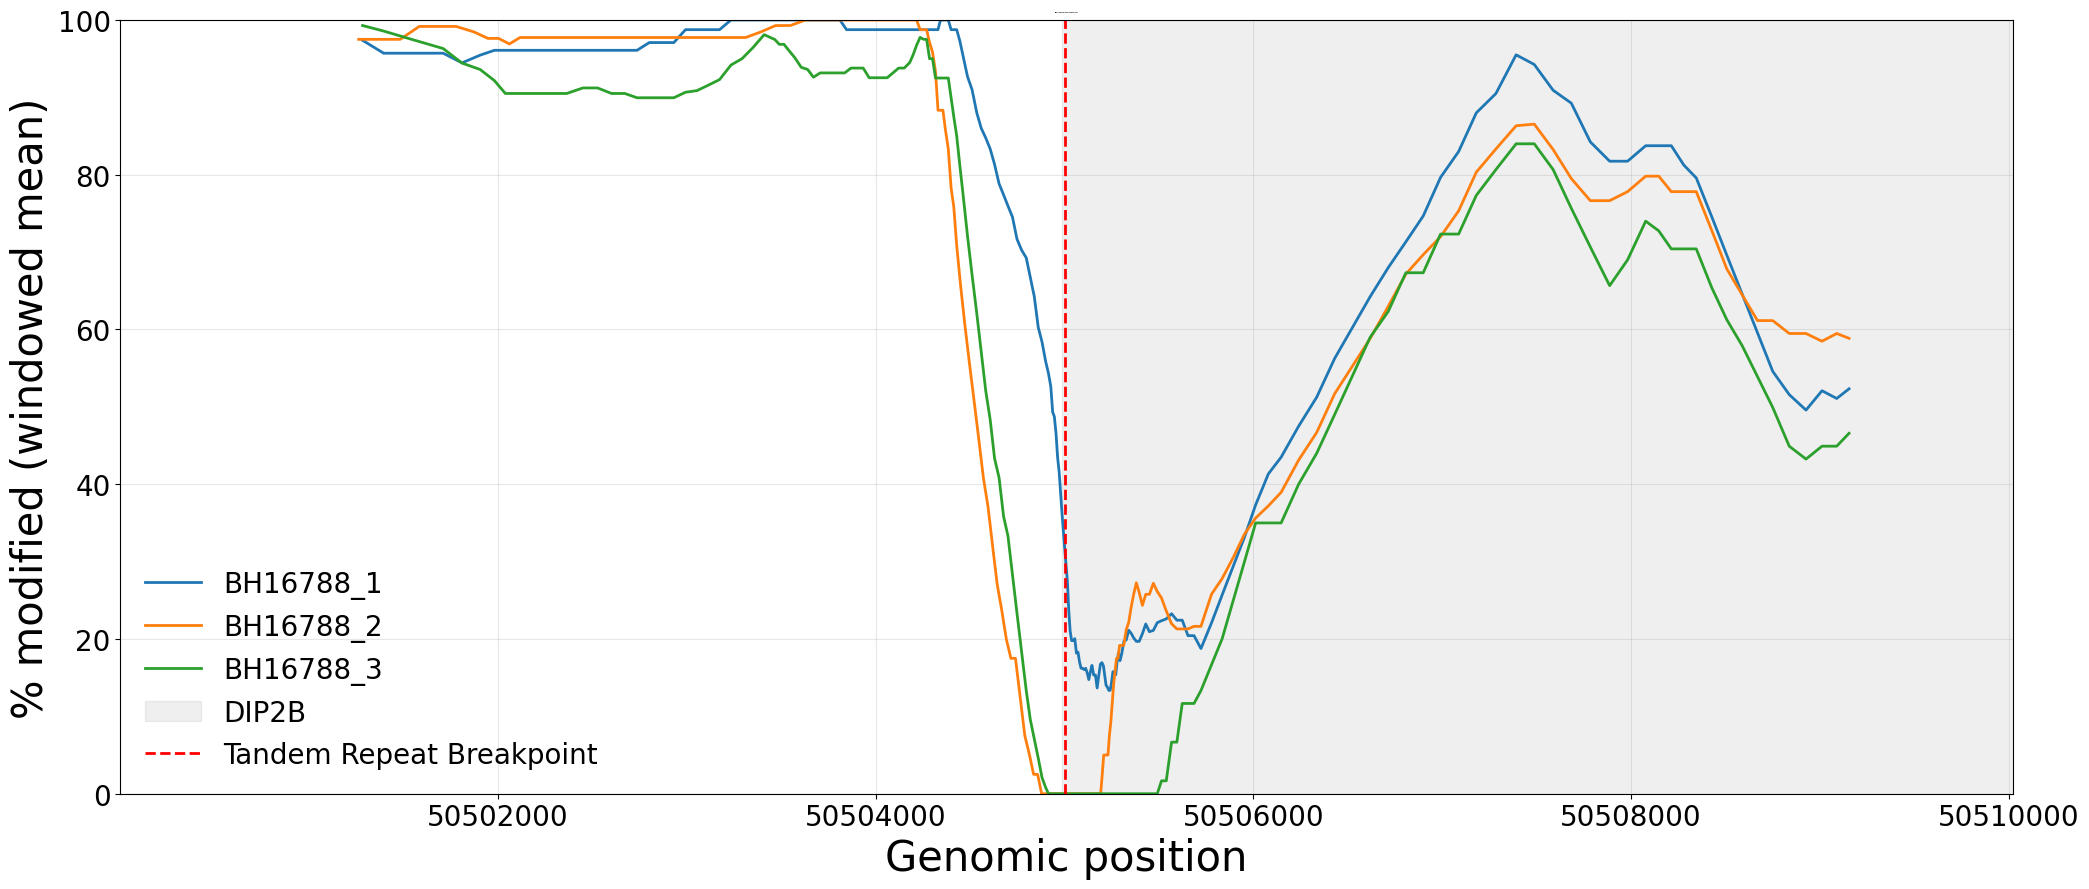

In [29]:
fig, ax = draw_series(
    series, region,
    annotate_spans=[("DIP2B", 50504985, 50510022)],
    annotate_vlines=[("Tandem Repeat Breakpoint", 50505001)],
    out_path="BH16788_DIP2B/DIP2B.methylation.pdf",
    show=False,
    font_title=0, font_label=30, font_tick=20, font_legend=20, 
)

In [21]:
beds = {
    "N01_BH16732_P_1": "../../GREGoR_adaptive_sampling/34-36_Gregor_Trio/34-36_Gregor_Trio_barcode34_modkit/34-36_Gregor_Trio_barcode34.HP_1.bed",
    "N01_BH16732_P_2": "../../GREGoR_adaptive_sampling/34-36_Gregor_Trio/34-36_Gregor_Trio_barcode34_modkit/34-36_Gregor_Trio_barcode34.HP_2.bed",
    "N01_BH16732_M_1": "../../GREGoR_adaptive_sampling/34-36_Gregor_Trio/34-36_Gregor_Trio_barcode35_modkit/34-36_Gregor_Trio_barcode35.HP_1.bed",
    "N01_BH16732_M_2": "../../GREGoR_adaptive_sampling/34-36_Gregor_Trio/34-36_Gregor_Trio_barcode35_modkit/34-36_Gregor_Trio_barcode35.HP_2.bed",
    "N01_BH16732_F": "../../GREGoR_adaptive_sampling/34-36_Gregor_Trio/34-36_Gregor_Trio_barcode36_modkit/34-36_Gregor_Trio_barcode36.HP_ungrouped.bed",
    # "N01_BH16732_F_2": "../../GREGoR_adaptive_sampling/34-36_Gregor_Trio/34-36_Gregor_Trio_barcode36_modkit/34-36_Gregor_Trio_barcode36.HP_2.bed",
}
region = ("chr1", 156590000, 156595000)
# 1) Prepare once (you can tweak window_size here)
series, raw = prepare_series(
    beds, region,
    window_size=20, min_points_for_smooth=5,
    drop_first_col=False,   # set to False if no leading index column
    percent_col=10         # adjust to your file schema
)


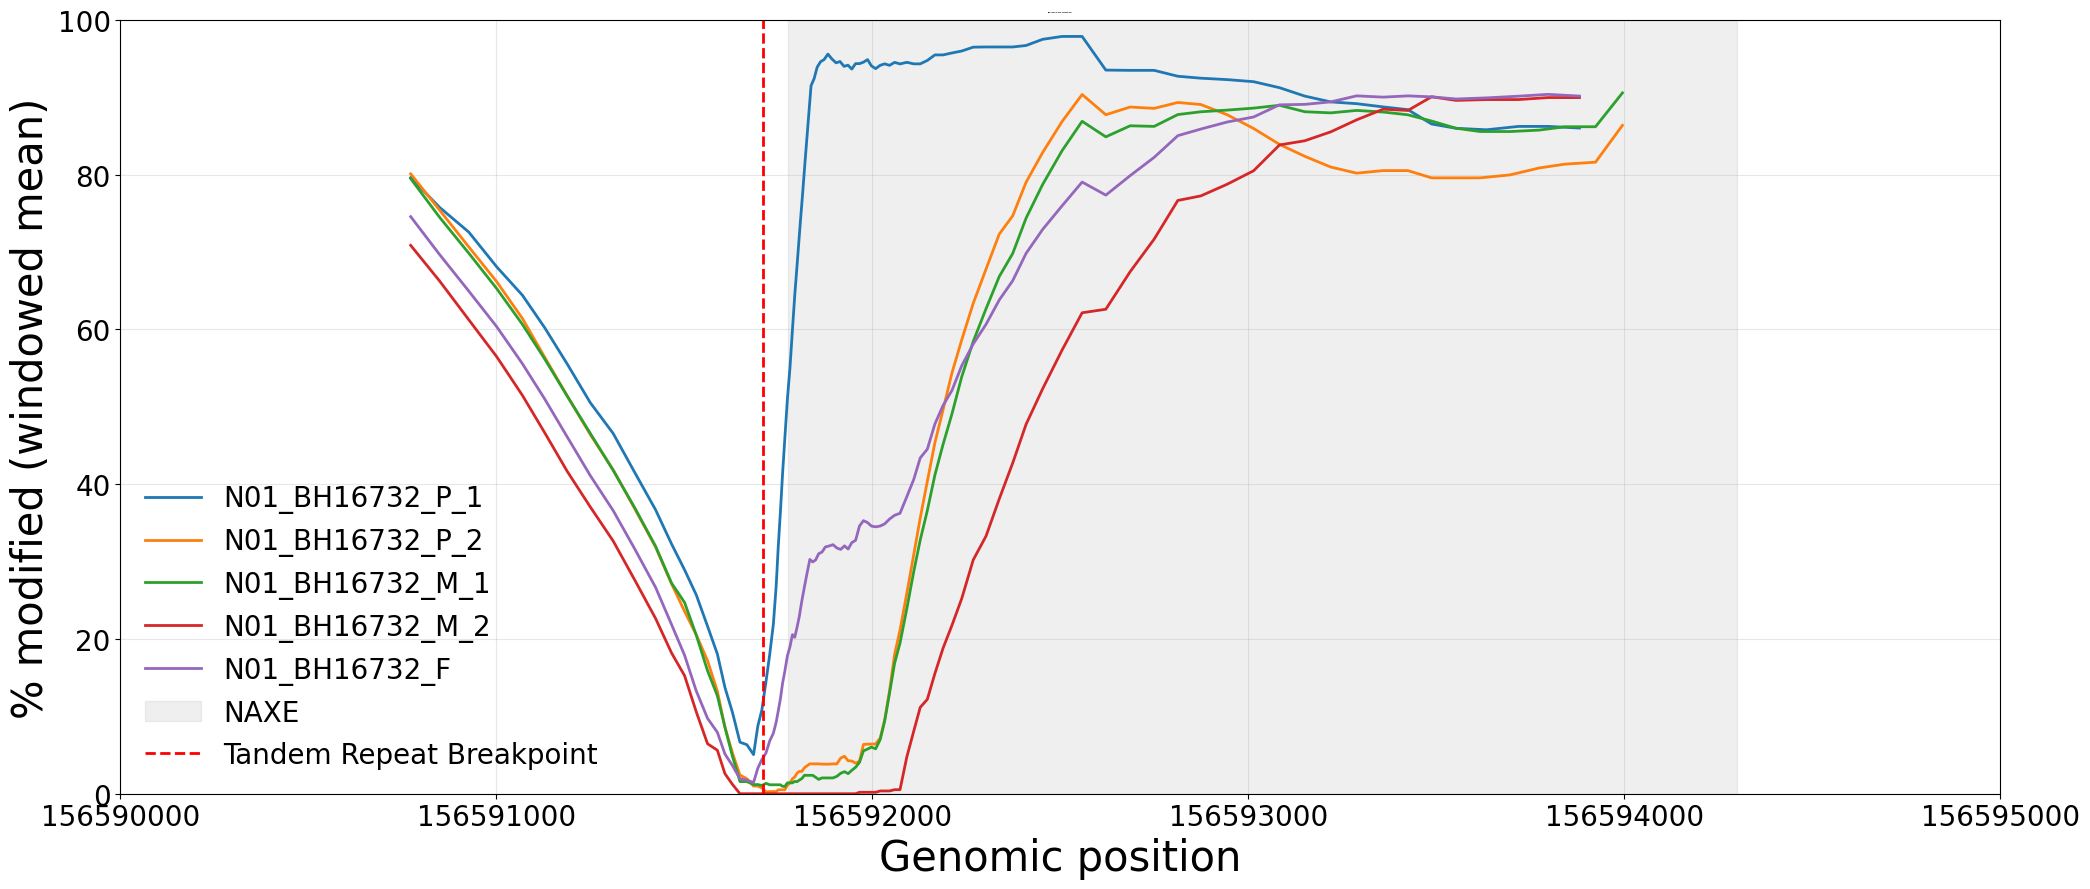

In [24]:
fig, ax = draw_series(
    series, region,
    annotate_spans=[("NAXE", 156591776, 156594299)],
    annotate_vlines=[("Tandem Repeat Breakpoint", 156591710)],
    out_path="BH16732_NAXE/NAXE.methylation.pdf",
    show=False,
    font_title=0, font_label=30, font_tick=20, font_legend=20, legend_loc="lower left"
)